## Figures in the paper

This notebook generates all the figures that are included in the paper. Note that the paper contains figures that have been generated here and labelled on powerpoint, or certain maps created on QGIS.

In [5]:
#this cell is necessary to not get any errors when loading shapefiles 
import os
os.environ["PROJ_DATA"] = "/Users/ppuente/github/detection_comparison-CRB/comparison-env/lib/python3.11/site-packages/fiona/proj_data"
# replace the /Users/ppuente/github/detection_comparison-CRB/comparison-env to your own path and what you named the your environment (ie. comparison-env)

In [18]:
#packages 
import geopandas as gpd
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

Figure 3 (a)

In [7]:
#load the sentinel and landsat shapefiles 
landsat = gpd.read_file('../data/zenodo-data/shapefiles/landsat_inundated_shapefile.shp')
sentinel = gpd.read_file('../data/zenodo-data/shapefiles/sentinel_inundated_shapefile.shp')

#crb Huc4 
crb_huc4_shape = gpd.read_file('../data/shapefiles/crb_huc4.shp')

#upper and lower basin outline 
upper_hucs = gpd.read_file('../data/shapefiles/UCRB_statelines.shp')
lower_hucs = gpd.read_file('../data/shapefiles/LCRB_statelines.shp')
upper_hucs = upper_hucs.to_crs(epsg = 3857)
lower_hucs = lower_hucs.to_crs(epsg=3857)

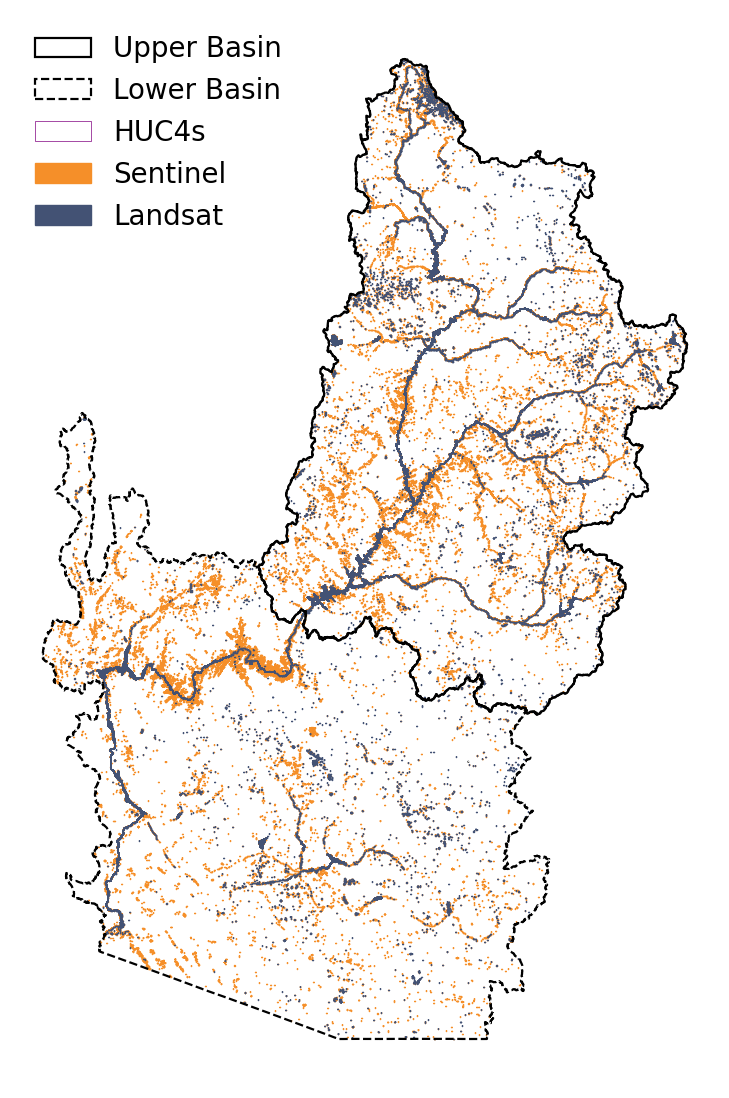

In [12]:
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(10,14))

#inundation from landsat and sentinel
landsat.plot(ax = ax, edgecolor = '#435274', facecolor = '#435274', zorder = 4)
sentinel.plot(ax = ax, edgecolor ="#F58F29" , facecolor = '#F58F29', zorder = 3)

ax.axis('off')

#upper and lower basin division 
upper_hucs.plot(ax=ax, edgecolor = 'black', zorder = 6, facecolor = 'none', linewidth = 1.6)
lower_hucs.plot(ax = ax, edgecolor ='black', zorder = 6, facecolor = 'none', linewidth = 1.6, linestyle = '--')

# Patch for shaded HUCs
sentinel_patch = mpatches.Patch(facecolor='#F58F29', edgecolor='#F58F29', label='Sentinel')
landsat_patch = mpatches.Patch(facecolor='#435274', edgecolor='#435274', label='Landsat')
upper_patch = mpatches.Patch(facecolor='none', edgecolor='black', linewidth= 1.6, label='Upper Basin')
lower_patch = mpatches.Patch(facecolor='none', edgecolor='black', linestyle='--', linewidth= 1.6, label='Lower Basin')

# # Combine all into one legend
legend_handles = [upper_patch, lower_patch,huc4_patch, sentinel_patch, landsat_patch]

# Add legend to plot
ax.legend(handles=legend_handles, loc='upper left', frameon=False, fontsize=20)
plt.savefig('../results/figures/fig3a_inundation_map.jpg',bbox_inches ='tight', dpi = 600)

plt.show()

Figure 3(b) 

In [26]:
zonal_data = pd.read_csv('../data/huc4_zonal_stats.csv')

#size of pixel 
pixel_area = 10**2 #(meters^2) from literature
#convert to kilometers
km_scale = 1e6

#add calculations of area 
zonal_data['area_inundated'] = (zonal_data.count_inundated * pixel_area) / km_scale

huc4_list = list(np.unique(zonal_data.huc4))

#subset the CRB dataset into upper and lower basin 
upper_df = zonal_data[zonal_data['huc4'].isin(huc4_list[0:8])]
lower_df = zonal_data[zonal_data['huc4'].isin(huc4_list[8:15])]

#sum inundation based on upper and lower 
ucrb_sum = upper_df.groupby('name')['area_inundated'].sum()
lcrb_sum = lower_df.groupby('name')['area_inundated'].sum()

plot_df = pd.DataFrame({
    'Upper Basin': ucrb_sum, 
    'Lower Basin': lcrb_sum
}).T #transpose to make basins the rows and dataset the columns 

In [27]:
plot_df

name,landsat,sentinel
Upper Basin,2687.6038,4344.8619
Lower Basin,1597.0349,3363.2984


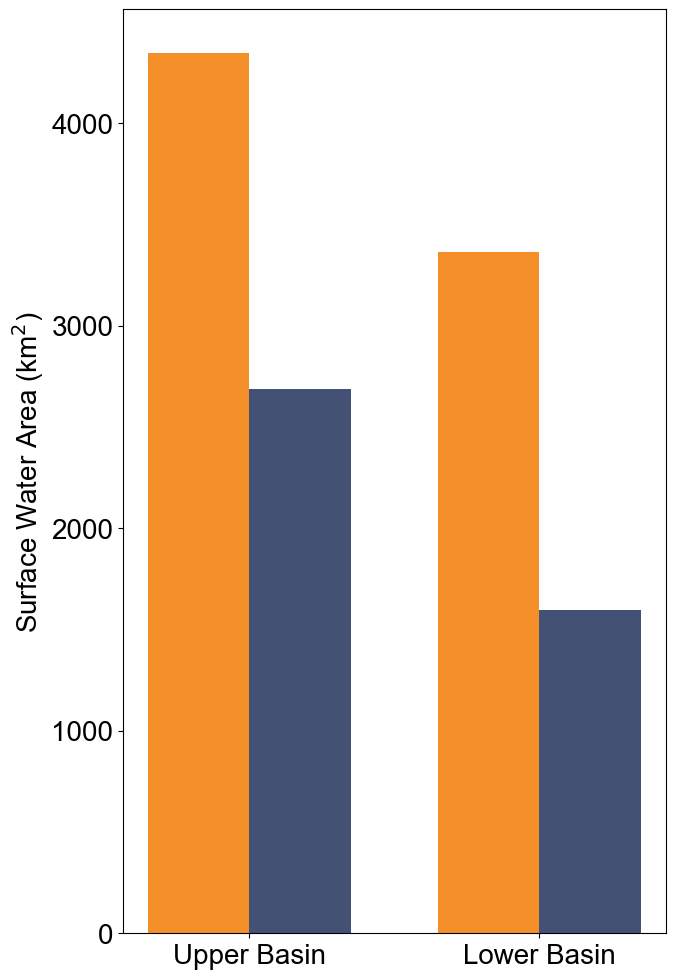

In [30]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'DejaVu Sans']
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(figsize=(7, 12))
x = np.arange(len(plot_df))  # the label locations
width = 0.35  # the width of the bars
rects1 = ax.bar(x - width/2, plot_df['sentinel'], width, label='Sentinel', color = '#F58F29') 
rects2 = ax.bar(x + width/2, plot_df['landsat'], width, label='Landsat', color = '#435274')
ax.set_ylabel('Surface Water Area (km$^2$)', fontsize = 20)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)

plt.savefig('../results/figures/fig3b_total_inundation_bars.jpg', bbox_inches ='tight', dpi = 600)
plt.show()

Figure 3(c)

In [39]:
#pivot the dataframe 
data_pivot_df = zonal_data.pivot(index = 'huc4', columns = 'name', values = 'area_inundated').reset_index()
#get rid of the name column 
data_pivot_df.columns.name = None

#we use Landsat as the baseline and calculcate the percent change 
data_pivot_df['percent_change'] = ((data_pivot_df['sentinel'] - data_pivot_df['landsat'])/data_pivot_df['landsat'])*100

In [40]:
data_pivot_df

,huc4,landsat,sentinel,percent_change
0,1401,257.5603,425.8831,65.352774
1,1402,145.9827,250.4313,71.548615
2,1403,93.3596,305.2648,226.977408
3,1404,723.0331,981.6166,35.763715
4,1405,133.6071,294.4829,120.409619
5,1406,415.6213,732.9681,76.354797
6,1407,635.3877,852.0026,34.091768
7,1408,283.0520,502.2125,77.427646
8,1501,666.4098,1895.0293,184.363960
9,1502,120.3118,178.6826,48.516272


In [42]:
#map the huc4 id's to strings so that we can join the dataset to the shapefile 
data_pivot_df['huc4'] = data_pivot_df['huc4'].map(str)

huc4_change = crb_huc4_shape.merge(data_pivot_df, on = 'huc4')

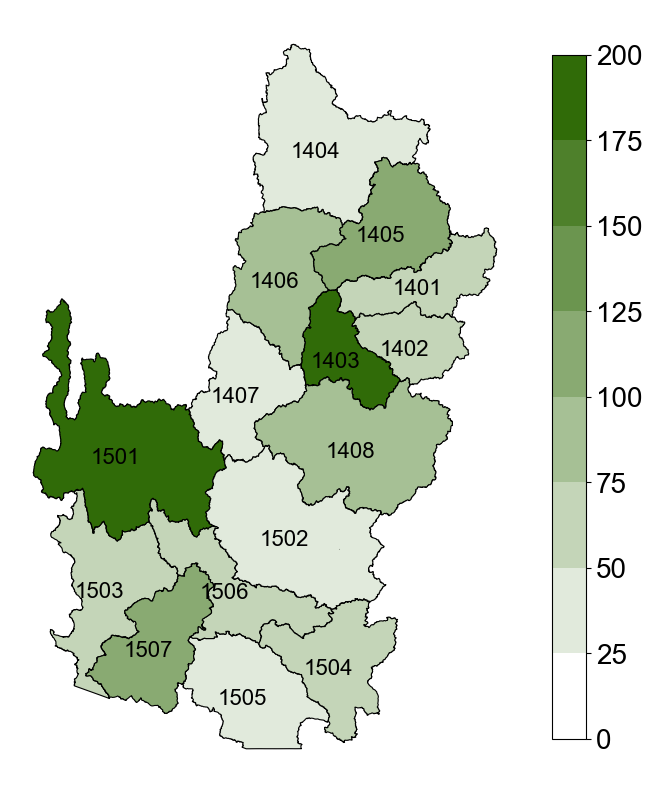

In [46]:
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(1, 1, figsize=(7, 12))
#range for the legend
vmin = 0; vmax = 200
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_ratio',
    [
        (0.0, 'white'),   # white
        (1.0, '#306b08')    # dark green
    ],
    N=8
)

#plot
huc4_change.plot(ax = ax, column = 'percent_change', legend = True, vmin = vmin, vmax = vmax, cmap=cmap, edgecolor='0', linewidth=0.8, legend_kwds={'shrink': 0.6})
ax.axis('off')

# Add HUC4 labels
for idx, row in huc4_change.iterrows():
    ax.text(row.geometry.centroid.x - 8e4, row.geometry.centroid.y - 3e4, 
               row["huc4"], fontsize=16, color='black')
    
ax.axis('off')
plt.tight_layout()
plt.savefig('../results/figures/fig3c_percent_change.jpg', bbox_inches='tight', dpi=600)
plt.show()